# Urdu Question Generation — from scratch (standalone notebook)

**Assignment 01, Generative AI (Fall 2026).** Given an Urdu sentence with the answer wrapped
in `<ans> … </ans>`, generate the question that span answers.

Everything is in this one notebook — data preparation, tokenizer, model, training, decoding,
evaluation, figures and result tables. Nothing is imported from external `.py` files. (The
repository also contains the same pipeline split into a `src/` package plus a thin wrapper
notebook, for readers who prefer modules; this notebook is the self-contained version.)

**Constraints followed:** RNN encoder–decoder with attention, built only from `nn.Embedding`,
`nn.LSTM`, `nn.Linear`. No pretrained weights, no Transformers, no off-the-shelf seq2seq.
Own SentencePiece vocabulary (8k).

| Kaggle setting | Value |
|---|---|
| Accelerator | **GPU T4 x2** |
| Internet | **On** (to download the dataset) |

Run the cells top to bottom. Total time ≈ 90 min (training dominates).

**Produces** (zipped at the end): `data/{train,valid,wiki}.tsv`, `artifacts/ur_sp.model`,
`artifacts/best.pt`, `results/metrics.json`, `results/samples.tsv`, `results/human_eval.csv`,
`results/tables.md`, `results/figures/{length_hist,loss_curve,attention}.png`.

## 0 · Environment

`datasets` and `torch` ship with the Kaggle image; install the
few extras (and an Arabic-script font so the attention figure renders Urdu).

In [3]:
!pip -q install sentencepiece sacrebleu rouge-score arabic-reshaper python-bidi
!apt-get -qq install -y fonts-noto-core > /dev/null 2>&1 || true
import torch, sys
print("python :", sys.version.split()[0])
print("torch  :", torch.__version__)
print("GPU    :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — enable GPU!")
print("kernels:", (torch.ones(3, device="cuda") * 2).tolist() if torch.cuda.is_available() else "n/a")

python : 3.12.13
torch  : 2.10.0+cu128
GPU    : Tesla T4
kernels: [2.0, 2.0, 2.0]


## 1 · Configuration

Every tunable number lives here. The **fixed** values come straight from the manual
(vocab 8k; embedding 256; hidden 512; dropout 0.3; batch 64; 10–15 epochs; beam 3–5).
The rest (learning rate, teacher-forcing ratio, gradient clip, length caps after
tokenisation) are our choices and are explained where they are used.

In [4]:
import os, csv, math, time, random, json, unicodedata, contextlib, tempfile
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from IPython.display import display, Markdown   # inline tables / figures

SEED = 1234
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- output folders (Kaggle working dir is writable) ----
DATA, ART, RES = Path("data"), Path("artifacts"), Path("results")
FIG = RES / "figures"
for d in (DATA, ART, RES, FIG):
    d.mkdir(parents=True, exist_ok=True)

# ---- special tokens; ids are pinned when SentencePiece is trained ----
PAD, UNK, BOS, EOS = 0, 1, 2, 3
ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
UNK_SURFACE = "\u2047"          # SentencePiece renders <unk> as this glyph

# ---- Task 1: data preparation ----
SENT_DELIMS = "\u06d4\u061f!"  # Urdu full stop, Urdu question mark, exclamation
MAX_SRC, MAX_TGT = 60, 25        # whitespace-token caps (manual)

# ---- Task 3: model (manual) ----
VOCAB_SIZE, EMB_DIM, HIDDEN = 8000, 256, 512
ENC_LAYERS, DEC_LAYERS, DROPOUT = 2, 2, 0.3

# ---- training (our schedule) ----
BATCH_SIZE, EPOCHS = 64, 15
LR, GRAD_CLIP, TEACHER_FORCING = 1e-3, 1.0, 0.5
LR_FACTOR, LR_PATIENCE = 0.5, 1
MAX_SRC_TOK, MAX_TGT_TOK = 80, 40   # subword-length caps
DEBUG_SUBSET = 10_000

# ---- decoding ----
BEAM_SIZE, MAX_DECODE, LENGTH_PENALTY = 5, 40, 0.6
N_SAMPLES, HUMAN_N, HUMAN_SEED = 60, 50, 7

print("device:", DEVICE)

device: cuda


## 2 · Task 1 — Data preparation

Load **UQA** (train + validation) and **Wiki-UQA** (out-of-domain test). For each answerable
row: locate the *sentence* that contains the answer using its character offset, verify the
offset, wrap the span in `<ans> … </ans>`, and drop pairs longer than 60 (source) / 25
(target) whitespace tokens.

Only the answer sentence is used, not the whole paragraph — a from-scratch RNN on ~75k pairs
cannot learn to read a 300-token context (Du et al., 2017).

*Schema note:* the current HuggingFace copy of UQA has flat `answer` / `answer_start` /
`is_impossible` fields, not the nested `answers` dict shown in the appendix. `get_answer`
handles both.

In [5]:
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
import datasets
datasets.utils.logging.set_verbosity_error()
datasets.disable_progress_bars()
from datasets import load_dataset

uqa  = load_dataset("uqa/UQA")        # splits: train, validation
wiki = load_dataset("uqa/Wiki-UQA")   # out-of-domain test (single split)
print(uqa)
ex = uqa["train"][0]
print("keys    :", list(ex.keys()))
print("question:", ex["question"])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
keys    : ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start']
question: بیونس نے کب مقبولیت حاصل کرنا شروع کی؟


In [6]:
def split_sentences(text):
    """Yield (start, end, sentence) with character offsets into `text`."""
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

def get_answer(example):
    """Return (answer_text, answer_start) or None. Handles the flat UQA schema
    and the nested SQuAD-style `answers` dict."""
    a = example.get("answers")
    if isinstance(a, dict):
        if not a.get("text"):
            return None
        return a["text"][0], int(a["answer_start"][0])
    if example.get("is_impossible"):
        return None
    ans, start = example.get("answer"), example.get("answer_start")
    if not ans or start is None or int(start) < 0:
        return None
    return ans, int(start)

def make_pair(example, max_src=MAX_SRC, max_tgt=MAX_TGT):
    """Return (source, target) or None if the row is unusable."""
    got = get_answer(example)
    if got is None:
        return None
    a_text, a_start = got
    a_text   = unicodedata.normalize("NFC", a_text).strip()
    context  = unicodedata.normalize("NFC", example["context"])
    question = unicodedata.normalize("NFC", example["question"])
    if not a_text:
        return None
    for s, e, sent in split_sentences(context):
        if not (s <= a_start < e):
            continue
        rel = a_start - s
        if sent[rel:rel + len(a_text)] != a_text:   # small offset drift -> local search
            rel = sent.find(a_text)
            if rel == -1:
                return None
        src = (sent[:rel] + " " + ANS_OPEN + " " + a_text + " "
               + ANS_CLOSE + " " + sent[rel + len(a_text):])
        src = " ".join(src.split())
        tgt = " ".join(question.split())
        if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
            return None
        return src, tgt
    return None

def build_split(rows, out_path):
    """Write `out_path` (tab-separated source<TAB>target) and return (pairs, stats)."""
    pairs, src_len, tgt_len, n_answerable = [], [], [], 0
    for ex in rows:
        if get_answer(ex) is not None:
            n_answerable += 1
        p = make_pair(ex)
        if p:
            pairs.append(p)
            src_len.append(len(p[0].split()))
            tgt_len.append(len(p[1].split()))
    with open(out_path, "w", encoding="utf-8", newline="\n") as f:
        for src, tgt in pairs:
            f.write(src.replace("\t", " ") + "\t" + tgt.replace("\t", " ") + "\n")
    stats = dict(raw_rows=len(rows), answerable_rows=n_answerable,
                 pairs=len(pairs),
                 mean_src=round(float(np.mean(src_len)), 2) if src_len else 0.0,
                 mean_tgt=round(float(np.mean(tgt_len)), 2) if tgt_len else 0.0)
    print(f"{str(out_path):<18} raw={stats['raw_rows']:>6}  answerable={stats['answerable_rows']:>6}"
          f"  pairs={stats['pairs']:>6}  mean src/tgt={stats['mean_src']}/{stats['mean_tgt']}")
    return pairs, stats

wiki_rows = wiki["test"] if "test" in wiki else wiki[list(wiki)[0]]
train_pairs, st_train = build_split(uqa["train"],       DATA / "train.tsv")
valid_pairs, st_valid = build_split(uqa["validation"],  DATA / "valid.tsv")
wiki_pairs,  st_wiki  = build_split(wiki_rows,          DATA / "wiki.tsv")

DATA_STATS = {"train": st_train, "valid": st_valid, "wiki": st_wiki}
(RES / "data_stats.json").write_text(json.dumps(DATA_STATS, indent=2, ensure_ascii=False), encoding="utf-8")

# Table 1 preview + two sample pairs, shown inline
display(Markdown("**Table 1 — dataset statistics**"))
display(pd.DataFrame(DATA_STATS).T)
for src, tgt in train_pairs[:2]:
    print("\nSRC", src)
    print("TGT", tgt)

data/train.tsv     raw=124745  answerable= 83018  pairs= 75236  mean src/tgt=32.59/11.92
data/valid.tsv     raw= 16824  answerable= 11169  pairs= 10043  mean src/tgt=33.23/12.29
data/wiki.tsv      raw=   210  answerable=   209  pairs=   177  mean src/tgt=31.69/11.42


**Table 1 — dataset statistics**

,raw_rows,answerable_rows,pairs,mean_src,mean_tgt
train,124745.0,83018.0,75236.0,32.59,11.92
valid,16824.0,11169.0,10043.0,33.23,12.29
wiki,210.0,209.0,177.0,31.69,11.42



SRC ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
TGT بیونس نے کب مقبولیت حاصل کرنا شروع کی؟

SRC ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
TGT جب وہ بڑی ہو رہی تھی تو بیونس نے کن شعبوں میں مقابلہ کیا؟


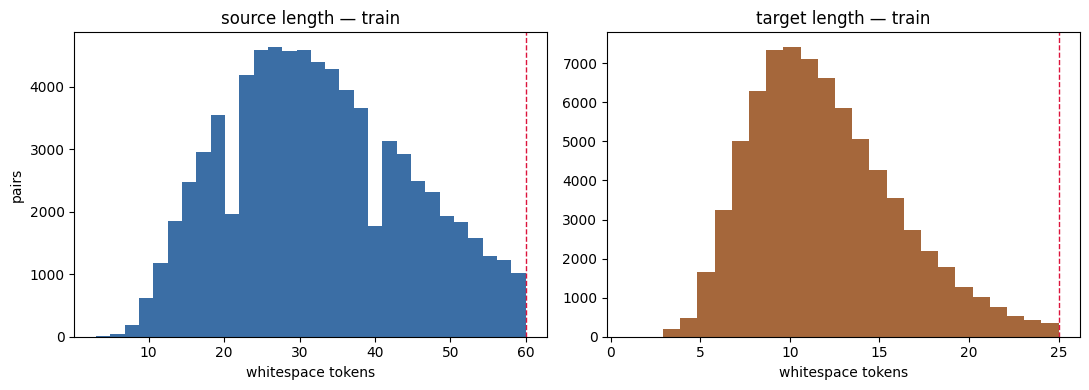

Figure 2 -> results/figures/length_hist.png


In [7]:
import matplotlib.pyplot as plt   # notebook backend: figures render inline AND save

tr_s = [len(s.split()) for s, _ in train_pairs]
tr_t = [len(t.split()) for _, t in train_pairs]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(tr_s, bins=30, color="#3b6ea5"); ax[0].axvline(MAX_SRC, color="crimson", ls="--", lw=1)
ax[0].set_title("source length — train"); ax[0].set_xlabel("whitespace tokens"); ax[0].set_ylabel("pairs")
ax[1].hist(tr_t, bins=25, color="#a5673b"); ax[1].axvline(MAX_TGT, color="crimson", ls="--", lw=1)
ax[1].set_title("target length — train"); ax[1].set_xlabel("whitespace tokens")
fig.tight_layout(); fig.savefig(FIG / "length_hist.png", dpi=120); plt.show()
print("Figure 2 -> results/figures/length_hist.png")

## 3 · Task 2 — SentencePiece tokenizer

Train a **unigram** subword model on the training text only (`vocab_size=8000`,
`character_coverage=1.0`). `<ans>` / `</ans>` are user-defined symbols so a tag is always
one token; ids are pinned pad=0, unk=1, bos=2, eos=3.

Unigram (rather than BPE) keeps frequent whole words and splits only rarer inflected forms
into stem + affix pieces — a good fit for Urdu's rich morphology.

In [8]:
import sentencepiece as spm

with open(DATA / "sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")

@contextlib.contextmanager
def _quiet_stderr():
    """Send SentencePiece's C++ LOG(INFO) flood (fd 2) to a temp file."""
    saved = os.dup(2); tmp = tempfile.TemporaryFile()
    os.dup2(tmp.fileno(), 2)
    try:
        yield
    finally:
        os.dup2(saved, 2); os.close(saved); tmp.close()

with _quiet_stderr():
    spm.SentencePieceTrainer.train(
        input=str(DATA / "sp_corpus.txt"), model_prefix=str(ART / "ur_sp"),
        vocab_size=VOCAB_SIZE, model_type="unigram", character_coverage=1.0,
        user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
        pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS,
        pad_piece="<pad>", unk_piece="<unk>", bos_piece="<s>", eos_piece="</s>",
    )

sp = spm.SentencePieceProcessor(model_file=str(ART / "ur_sp.model"))
print("vocab size:", sp.get_piece_size())
probe = f"کتاب {ANS_OPEN} علی {ANS_CLOSE} ہے"
pieces = sp.encode(probe, out_type=str)
for tag in (ANS_OPEN, ANS_CLOSE):
    assert pieces.count(tag) == 1, (tag, pieces)
    print(f"  {tag} -> id {sp.piece_to_id(tag)} (one token in context)")

vocab size: 8000
  <ans> -> id 4 (one token in context)
  </ans> -> id 5 (one token in context)


In [9]:
# Five tokenised examples + a note on how Urdu morphology is split (Task 2.3).
lines = ["Five tokenised training examples\n" + "=" * 34 + "\n"]
for src, tgt in train_pairs[:5]:
    sp_pieces = sp.encode(src, out_type=str)
    tp_pieces = sp.encode(tgt, out_type=str)
    rt = sp.decode(sp.encode(tgt, out_type=int)) == " ".join(tgt.split())
    block = (f"SRC  {src}\n     {' '.join(sp_pieces)}   ({len(sp_pieces)} pieces)\n"
             f"TGT  {tgt}\n     {' '.join(tp_pieces)}   ({len(tp_pieces)} pieces)\n"
             f"     round-trip ok: {rt}\n")
    print(block)
    lines.append(block)
lines.append(
    "\nUrdu morphology: the unigram model keeps common function words whole "
    "(کے، میں، سے) and breaks inflected / compound forms into a stem plus affix "
    "pieces (plural and oblique endings, the izafat 'ی'). Rare proper nouns "
    "fragment into near-character pieces, which is where most copy errors and "
    "<unk>-like behaviour come from.\n")
(RES / "tokenizer_examples.txt").write_text("".join(lines), encoding="utf-8")
print("wrote results/tokenizer_examples.txt")

SRC  ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
     ▁ہی وسٹن ▁، ▁ٹیکساس ▁میں ▁پیدا ▁ہوئی ▁اور ▁اس ▁کی ▁پر ورش ▁ہوئی ▁، ▁اس ▁نے ▁ بچپن ▁میں ▁مختلف ▁گانے ▁اور ▁رقص ▁کے ▁مقابل وں ▁میں ▁پرفارم ▁کیا ▁، ▁اور ▁ <ans> ▁1990 ▁کی ▁دہائی ▁کے ▁آخر ▁میں ▁ </ans> ▁R & B ▁گرل ▁گروپ ▁ڈسٹ نی ▁چائلڈ ▁کے ▁لیڈ ▁گلوکار ▁کی ▁حیثیت ▁سے ▁شہرت ▁حاصل ▁کی۔   (58 pieces)
TGT  بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
     ▁بیونس ▁نے ▁کب ▁مقبولیت ▁حاصل ▁کرنا ▁شروع ▁کی ؟   (9 pieces)
     round-trip ok: True

SRC  ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
     ▁ہی وسٹن ▁، ▁ٹیکساس ▁میں ▁پیدا ▁اور ▁پر ورش ▁پائی ▁، ▁اس ▁نے ▁ بچپن ▁میں ▁مختلف ▁ <ans> ▁گانے ▁اور ▁رقص ▁ </a

## 4 · Data pipeline

`QGDataset` tokenises a `source<TAB>target` line on demand; targets get `<s> … </s>`.
`collate_batch` sorts a batch by source length (so the encoder can pack the sequence and
never compute over padding), pads to `PAD`, and returns a boolean pad mask for the
attention layer. The decoder is trained to predict `tgt[:, 1:]` from `tgt[:, :-1]` (the
standard teacher-forced shift).

In [10]:
def load_pairs(path):
    out = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.count("\t") == 1:
                out.append(tuple(line.split("\t")))
    return out

class QGDataset(Dataset):
    def __init__(self, path, sp, max_src=MAX_SRC_TOK, max_tgt=MAX_TGT_TOK):
        self.pairs = load_pairs(path) if isinstance(path, (str, Path)) else list(path)
        self.sp, self.max_src, self.max_tgt = sp, max_src, max_tgt
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        s, t = self.pairs[i]
        s_ids = self.sp.encode(s, out_type=int)[: self.max_src]
        t_ids = [BOS, *self.sp.encode(t, out_type=int)[: self.max_tgt - 2], EOS]
        return {"src": torch.tensor(s_ids), "tgt": torch.tensor(t_ids),
                "src_text": s, "tgt_text": t}

def _pad(seqs, value):
    m = max(x.size(0) for x in seqs)
    out = torch.full((len(seqs), m), value, dtype=torch.long)
    for i, x in enumerate(seqs):
        out[i, : x.size(0)] = x
    return out

def collate_batch(batch):
    batch = sorted(batch, key=lambda b: b["src"].size(0), reverse=True)
    src = _pad([b["src"] for b in batch], PAD)
    tgt = _pad([b["tgt"] for b in batch], PAD)
    return {"src": src, "tgt": tgt,
            "src_lengths": torch.tensor([b["src"].size(0) for b in batch]),
            "src_key_padding_mask": src.eq(PAD),
            "src_texts": [b["src_text"] for b in batch],
            "tgt_texts": [b["tgt_text"] for b in batch]}

train_ds = QGDataset(DATA / "train.tsv", sp)
valid_ds = QGDataset(DATA / "valid.tsv", sp)
print(f"train {len(train_ds):,}  valid {len(valid_ds):,}")

train 75,236  valid 10,043


## 5 · Task 3 — Model

From primitives only.

* **Encoder** — embedding(256) → 2-layer **bidirectional** LSTM(512), dropout 0.3. The final
  forward+backward states are merged by a linear *bridge* (`tanh`) into the decoder's initial
  state (encoder is `2H`, decoder is `H`).
* **Bahdanau (additive) attention** — `eₜᵢ = vᵀ tanh(Wₑ hᵢ + W_d sₜ)`, softmax over source
  positions with padding masked to `-inf`, context `cₜ = Σᵢ αₜᵢ hᵢ`.
* **Decoder** — embedding(256) + the previous context vector (input feeding) → 2-layer
  LSTM(512) → attention → linear readout over `[sₜ ; cₜ ; embₜ]` to the 8k vocabulary.
* **Seq2Seq** — runs the teacher-forced loop and returns `logits [B, T-1, V]` and the
  attention tensor `[B, T-1, S]`.

In [11]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=PAD)
        self.drop = nn.Dropout(DROPOUT)
        self.rnn = nn.LSTM(EMB_DIM, HIDDEN, num_layers=ENC_LAYERS, batch_first=True,
                           bidirectional=True, dropout=DROPOUT if ENC_LAYERS > 1 else 0.0)
        self.bridge_h = nn.Linear(2 * HIDDEN, HIDDEN)
        self.bridge_c = nn.Linear(2 * HIDDEN, HIDDEN)
    def forward(self, src, src_lengths):
        emb = self.drop(self.emb(src))
        packed = pack_padded_sequence(emb, src_lengths.cpu(), batch_first=True, enforce_sorted=True)
        outs, (h, c) = self.rnn(packed)
        outs, _ = pad_packed_sequence(outs, batch_first=True, total_length=src.size(1))
        last_h = torch.cat([h[-2], h[-1]], dim=-1)
        last_c = torch.cat([c[-2], c[-1]], dim=-1)
        h0 = torch.tanh(self.bridge_h(last_h)).unsqueeze(0).repeat(DEC_LAYERS, 1, 1)
        c0 = torch.tanh(self.bridge_c(last_c)).unsqueeze(0).repeat(DEC_LAYERS, 1, 1)
        return outs, (h0.contiguous(), c0.contiguous())

class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W_enc = nn.Linear(2 * HIDDEN, HIDDEN, bias=False)
        self.W_dec = nn.Linear(HIDDEN, HIDDEN, bias=False)
        self.v = nn.Linear(HIDDEN, 1, bias=False)
    def keys(self, enc_outputs):
        return self.W_enc(enc_outputs)
    def forward(self, dec_state, enc_outputs, enc_keys, pad_mask):
        q = self.W_dec(dec_state).unsqueeze(1)
        scores = self.v(torch.tanh(enc_keys + q)).squeeze(-1)
        scores = scores.masked_fill(pad_mask, float("-inf"))
        w = torch.softmax(scores, dim=-1)
        ctx = torch.bmm(w.unsqueeze(1), enc_outputs).squeeze(1)
        return ctx, w

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=PAD)
        self.drop = nn.Dropout(DROPOUT)
        self.rnn = nn.LSTM(EMB_DIM + 2 * HIDDEN, HIDDEN, num_layers=DEC_LAYERS,
                           batch_first=True, dropout=DROPOUT if DEC_LAYERS > 1 else 0.0)
        self.attn = BahdanauAttention()
        self.out = nn.Linear(HIDDEN + 2 * HIDDEN + EMB_DIM, VOCAB_SIZE)
    def step(self, input_id, state, prev_ctx, enc_outputs, enc_keys, pad_mask):
        emb = self.drop(self.emb(input_id))
        rnn_in = torch.cat([emb, prev_ctx], dim=-1).unsqueeze(1)
        rnn_out, state = self.rnn(rnn_in, state)
        dec_state = rnn_out.squeeze(1)
        ctx, attn = self.attn(dec_state, enc_outputs, enc_keys, pad_mask)
        logits = self.out(self.drop(torch.cat([dec_state, ctx, emb], dim=-1)))
        return logits, state, ctx, attn

class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder(); self.decoder = Decoder()
    def encode(self, src, src_lengths):
        enc_outputs, state = self.encoder(src, src_lengths)
        return enc_outputs, self.decoder.attn.keys(enc_outputs), state
    def forward(self, src, src_lengths, pad_mask, tgt, teacher_forcing=0.5):
        B, T = tgt.size()
        enc_outputs, enc_keys, state = self.encode(src, src_lengths)
        ctx = src.new_zeros((B, 2 * HIDDEN), dtype=enc_outputs.dtype)
        input_id = tgt[:, 0]
        logits_seq, attn_seq = [], []
        for t in range(1, T):
            logits, state, ctx, attn = self.decoder.step(
                input_id, state, ctx, enc_outputs, enc_keys, pad_mask)
            logits_seq.append(logits); attn_seq.append(attn)
            input_id = tgt[:, t] if random.random() < teacher_forcing else logits.argmax(-1)
        return torch.stack(logits_seq, 1), torch.stack(attn_seq, 1)

def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [12]:
torch.manual_seed(SEED)
model = Seq2Seq().to(DEVICE)
N_PARAMS = count_parameters(model)
print(f"trainable parameters: {N_PARAMS:,}")   # Table 2

trainable parameters: 35,505,472


## 6 · Task 3 — Training

Adam (lr 1e-3) with `ReduceLROnPlateau`, gradient-norm clip 1.0, padding-masked
cross-entropy, teacher forcing 0.5. Loss is token-weighted (sum of per-token losses ÷
non-pad tokens). We save `artifacts/best.pt` (weights + config) on the lowest validation
loss — that is what evaluation and the front end load — and log every epoch to
`results/loss_log.csv`.

**Debug gate first:** one epoch on a 10k-pair subset. If the loss does not fall, there is a
bug — cheaper to catch in ~40 s than after an hour.

In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

def run_epoch(model, loader, optimizer=None, teacher_forcing=TEACHER_FORCING):
    training = optimizer is not None
    model.train(training)
    total_loss, total_tok = 0.0, 0
    for batch in loader:
        src = batch["src"].to(DEVICE); tgt = batch["tgt"].to(DEVICE)
        pad_mask = batch["src_key_padding_mask"].to(DEVICE)
        gold = tgt[:, 1:]
        ntok = gold.ne(PAD).sum().item()
        with torch.set_grad_enabled(training):
            logits, _ = model(src, batch["src_lengths"], pad_mask, tgt,
                              teacher_forcing=teacher_forcing if training else 1.0)
            loss = criterion(logits.reshape(-1, logits.size(-1)), gold.reshape(-1))
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
        total_loss += loss.item() * ntok; total_tok += ntok
    return total_loss / max(total_tok, 1)

In [14]:
# --- Debug gate: 10k pairs, 1 epoch, loss must fall ---
dbg_tr = DataLoader(Subset(train_ds, range(min(DEBUG_SUBSET, len(train_ds)))),
                    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch, drop_last=True)
dbg_va = DataLoader(Subset(valid_ds, range(min(DEBUG_SUBSET // 5, len(valid_ds)))),
                    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
torch.manual_seed(SEED)
dbg_model = Seq2Seq().to(DEVICE)
dbg_opt = torch.optim.Adam(dbg_model.parameters(), lr=LR)
t0 = time.time()
dbg_train = run_epoch(dbg_model, dbg_tr, dbg_opt)
dbg_val = run_epoch(dbg_model, dbg_va)
print(f"debug gate | train {dbg_train:.4f} | val {dbg_val:.4f} | ppl {math.exp(min(dbg_val,20)):.1f} | {time.time()-t0:.0f}s")
assert dbg_train < 8.5 and math.isfinite(dbg_val), "loss did not move — stop and fix the bug"
print("debug gate passed")
del dbg_model, dbg_opt

debug gate | train 5.8041 | val 5.5298 | ppl 252.1 | 43s
debug gate passed


In [15]:
# --- Full training ---
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_batch, num_workers=2, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

torch.manual_seed(SEED)
model = Seq2Seq().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                       factor=LR_FACTOR, patience=LR_PATIENCE)
MODEL_CFG = dict(vocab_size=VOCAB_SIZE, emb_dim=EMB_DIM, hidden_size=HIDDEN,
                 enc_layers=ENC_LAYERS, dec_layers=DEC_LAYERS, bidirectional=True,
                 dropout=DROPOUT, rnn_cell="lstm", attention="bahdanau",
                 tie_output_embedding=False)

log_rows, best_val, wall0 = [], math.inf, time.time()
with open(RES / "loss_log.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f); w.writerow(["epoch", "train_loss", "val_loss", "val_ppl", "lr", "seconds"])
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, optimizer)
        va = run_epoch(model, valid_loader)
        secs = time.time() - t0
        ppl = math.exp(min(va, 20)); lr = optimizer.param_groups[0]["lr"]
        scheduler.step(va)
        print(f"epoch {epoch:2d} | train {tr:.4f} | val {va:.4f} | ppl {ppl:7.2f} | lr {lr:.2e} | {secs:.0f}s")
        w.writerow([epoch, f"{tr:.5f}", f"{va:.5f}", f"{ppl:.3f}", f"{lr:.2e}", f"{secs:.1f}"]); f.flush()
        log_rows.append((epoch, tr, va))
        if va < best_val:
            best_val = va
            torch.save({"model_state": model.state_dict(), "model_cfg": MODEL_CFG,
                        "extra": {"val_loss": va, "epoch": epoch, "n_params": N_PARAMS}},
                       ART / "best.pt")
            print(f"           saved new best -> artifacts/best.pt")

WALL_CLOCK = time.time() - wall0
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
json.dump({"wall_clock_s": round(WALL_CLOCK, 1), "gpu": GPU_NAME, "epochs": EPOCHS,
           "batch_size": BATCH_SIZE, "best_val_loss": round(best_val, 4)},
          open(RES / "train_meta.json", "w"), indent=2)
print(f"\nbest val loss {best_val:.4f} (ppl {math.exp(min(best_val,20)):.2f}) | "
      f"wall-clock {WALL_CLOCK/60:.1f} min on {GPU_NAME}")

epoch  1 | train 5.4276 | val 4.4510 | ppl   85.71 | lr 1.00e-03 | 322s
           saved new best -> artifacts/best.pt
epoch  2 | train 4.7657 | val 4.0039 | ppl   54.81 | lr 1.00e-03 | 322s
           saved new best -> artifacts/best.pt
epoch  3 | train 4.3621 | val 3.8466 | ppl   46.84 | lr 1.00e-03 | 323s
           saved new best -> artifacts/best.pt
epoch  4 | train 4.0700 | val 3.6814 | ppl   39.70 | lr 1.00e-03 | 323s
           saved new best -> artifacts/best.pt
epoch  5 | train 3.8615 | val 3.6300 | ppl   37.71 | lr 1.00e-03 | 323s
           saved new best -> artifacts/best.pt
epoch  6 | train 3.7184 | val 3.5775 | ppl   35.79 | lr 1.00e-03 | 322s
           saved new best -> artifacts/best.pt
epoch  7 | train 3.5956 | val 3.6340 | ppl   37.86 | lr 1.00e-03 | 323s
epoch  8 | train 3.5251 | val 3.5912 | ppl   36.28 | lr 1.00e-03 | 323s
epoch  9 | train 3.3071 | val 3.5622 | ppl   35.24 | lr 5.00e-04 | 322s
           saved new best -> artifacts/best.pt
epoch 10 | train 3.2064

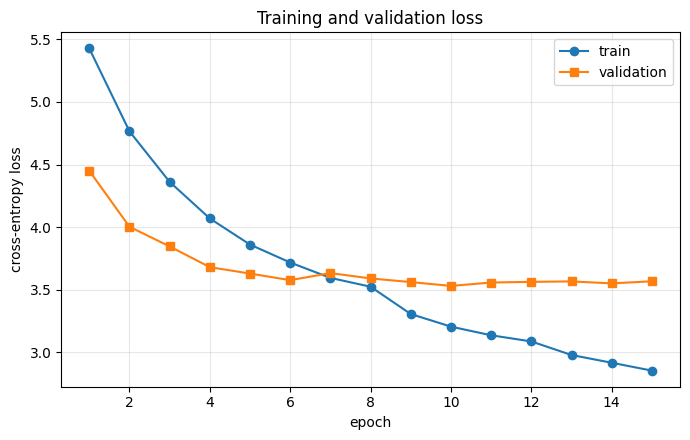

Figure 1 -> results/figures/loss_curve.png


In [16]:
# Figure 1 — training / validation loss per epoch
ep = [r[0] for r in log_rows]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ep, [r[1] for r in log_rows], "o-", label="train")
ax.plot(ep, [r[2] for r in log_rows], "s-", label="validation")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Training and validation loss"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG / "loss_curve.png", dpi=120); plt.show()
print("Figure 1 -> results/figures/loss_curve.png")

## 7 · Decoding

`greedy_decode` runs a whole batch, taking the argmax each step and stopping at `</s>`.
`beam_search` decodes one source at a time with the beam as the batch dimension: at each
step it scores every (beam × vocab) extension, keeps the global top-k, and remembers which
beam each came from. A length penalty `score / len^α` stops beam search from always
preferring very short questions. Both return the attention matrix for the chosen
hypothesis.

In [17]:
@torch.no_grad()
def greedy_decode(model, src, src_lengths, pad_mask, max_len=MAX_DECODE):
    model.eval()
    B = src.size(0)
    enc_outputs, enc_keys, state = model.encode(src, src_lengths)
    ctx = torch.zeros(B, 2 * HIDDEN, device=src.device)
    input_id = torch.full((B,), BOS, dtype=torch.long, device=src.device)
    done = torch.zeros(B, dtype=torch.bool, device=src.device)
    toks, attns = [[] for _ in range(B)], []
    for _ in range(max_len):
        logits, state, ctx, attn = model.decoder.step(input_id, state, ctx, enc_outputs, enc_keys, pad_mask)
        input_id = logits.argmax(-1); attns.append(attn)
        for b in range(B):
            if not done[b]:
                toks[b].append(int(input_id[b]))
        done |= input_id.eq(EOS)
        if bool(done.all()):
            break
    trim = lambda ids: [i for i in (ids[:ids.index(EOS)] if EOS in ids else ids) if i not in (PAD, BOS)]
    return [trim(t) for t in toks], torch.stack(attns, 1)

@torch.no_grad()
def beam_search(model, src, src_lengths, pad_mask, k=BEAM_SIZE, max_len=MAX_DECODE, alpha=LENGTH_PENALTY):
    model.eval()
    S = src.size(1)
    enc_outputs, enc_keys, state = model.encode(src, src_lengths)
    enc_outputs = enc_outputs.expand(k, S, -1).contiguous()
    enc_keys = enc_keys.expand(k, S, -1).contiguous()
    pad_k = pad_mask.expand(k, S).contiguous()
    state = (state[0].repeat(1, k, 1).contiguous(), state[1].repeat(1, k, 1).contiguous())
    ctx = torch.zeros(k, 2 * HIDDEN, device=src.device)
    seqs = torch.full((k, 1), BOS, dtype=torch.long, device=src.device)
    scores = torch.full((k,), float("-inf"), device=src.device); scores[0] = 0.0
    attn_hist = torch.zeros(k, 0, S, device=src.device)
    finished = []
    for _ in range(max_len):
        logits, state, ctx, attn = model.decoder.step(seqs[:, -1], state, ctx, enc_outputs, enc_keys, pad_k)
        lp = torch.log_softmax(logits, dim=-1)
        cand = (scores.unsqueeze(1) + lp).view(-1)
        top_scores, top_idx = cand.topk(k)
        beam_idx = torch.div(top_idx, lp.size(-1), rounding_mode="floor")
        tok_idx = top_idx % lp.size(-1)
        seqs = torch.cat([seqs[beam_idx], tok_idx.unsqueeze(1)], dim=1)
        scores = top_scores
        state = (state[0][:, beam_idx, :].contiguous(), state[1][:, beam_idx, :].contiguous())
        ctx = ctx[beam_idx]
        attn_hist = torch.cat([attn_hist[beam_idx], attn[beam_idx].unsqueeze(1)], dim=1)
        for b in range(k):
            if int(tok_idx[b]) == EOS:
                seq = seqs[b, 1:-1].tolist()
                finished.append((scores[b].item() / ((len(seq) + 1) ** alpha), seq))
                scores[b] = float("-inf")           # do not extend a finished beam
        if len(finished) >= k:
            break
    # Also rank the beams still running - otherwise one short beam that hit
    # </s> early beats better, longer, unfinished hypotheses.
    for b in range(k):
        if scores[b].item() != float("-inf"):
            seq = seqs[b, 1:].tolist()
            finished.append((scores[b].item() / ((len(seq) + 1) ** alpha), seq))
    finished.sort(key=lambda x: x[0], reverse=True)
    best = finished[0][1]
    return best[:best.index(EOS)] if EOS in best else best

## 8 · Task 4 — Evaluation

Same pipeline on **UQA validation** and **Wiki-UQA**, for greedy and beam (k=5):

* **BLEU-4** — `sacrebleu.corpus_bleu` on detokenised text
* **ROUGE-L** — mean F-measure, `rouge_score`
* **Perplexity** — `exp` of the teacher-forced cross-entropy of `best.pt`
* **`<unk>` %** — share of generated tokens rendered as `⁇` (U+2047)

Sanity band: BLEU-4 ≈ 6–13 on UQA-valid, lower on Wiki-UQA. Near 0 ⇒ a bug; above 30 ⇒
train/validation leakage.

In [18]:
import sacrebleu
from rouge_score import rouge_scorer

class _WsTokenizer:
    """rouge_score's default tokenizer keeps only [a-z0-9] after lowercasing,
    which deletes every Urdu character. Split on whitespace instead."""
    def tokenize(self, text):
        return text.split()

_ROUGE = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False, tokenizer=_WsTokenizer())

def score(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    rl = sum(_ROUGE.score(r, h)["rougeL"].fmeasure for h, r in zip(hyps, refs)) / max(len(refs), 1)
    unk = sum(h.count(UNK_SURFACE) for h in hyps) / max(1, sum(len(h.split()) for h in hyps))
    return {"BLEU-4": round(bleu, 2), "ROUGE-L": round(rl, 4), "unk_%": round(100 * unk, 3)}

# best checkpoint back into a fresh model
ckpt = torch.load(ART / "best.pt", map_location=DEVICE)
best_model = Seq2Seq().to(DEVICE); best_model.load_state_dict(ckpt["model_state"]); best_model.eval()

def perplexity(pairs):
    dl = DataLoader(QGDataset(pairs, sp), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
    return math.exp(min(run_epoch(best_model, dl), 20))

def decode_split(pairs, beam_max=3000):
    dl = DataLoader(QGDataset(pairs, sp), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
    greedy, refs, srcs = [], [], []
    for batch in dl:
        seqs, _ = greedy_decode(best_model, batch["src"].to(DEVICE), batch["src_lengths"],
                                batch["src_key_padding_mask"].to(DEVICE))
        greedy += [sp.decode(s) for s in seqs]
        refs += batch["tgt_texts"]; srcs += batch["src_texts"]
    n_beam = min(beam_max, len(pairs))
    beam = []
    for s, _ in pairs[:n_beam]:
        ids = sp.encode(s, out_type=int)[:MAX_SRC_TOK]
        src = torch.tensor([ids], device=DEVICE)
        beam.append(sp.decode(beam_search(best_model, src, torch.tensor([len(ids)]), src.eq(PAD))))
    return dict(src=srcs, ref=refs, greedy=greedy, beam=beam, n_beam=n_beam)

METRICS = {}
splits = {"UQA valid": valid_pairs, "Wiki-UQA": wiki_pairs}
outs = {}
for name, pairs in splits.items():
    o = decode_split(pairs); outs[name] = o
    ppl = round(perplexity(pairs), 3)
    m = o["n_beam"]                       # greedy and beam scored on the SAME m examples
    METRICS[name] = {
        "greedy": {**score(o["greedy"][:m], o["ref"][:m]), "PPL": ppl, "n_scored": m},
        f"beam(k={BEAM_SIZE})": {**score(o["beam"], o["ref"][:m]), "PPL": ppl, "n_scored": m},
    }
    if len(o["ref"]) > m:                 # FYI: greedy over the whole split
        gf = score(o["greedy"], o["ref"])
        print(f"{name}: greedy on all {len(o['ref'])} -> BLEU-4 {gf['BLEU-4']}, ROUGE-L {gf['ROUGE-L']}")
json.dump(METRICS, open(RES / "metrics.json", "w"), indent=2, ensure_ascii=False)
print(f"(Table 3: greedy and beam scored on the same {outs['UQA valid']['n_beam']} "
      f"validation examples; perplexity on the full split.)")
_rows = [{"split": sp_, "decoding": d, **{k: v for k, v in r.items() if k != "n_scored"}}
         for sp_, md_ in METRICS.items() for d, r in md_.items()]
display(Markdown("**Automatic metrics (Table 3)**"))
display(pd.DataFrame(_rows).set_index(["split", "decoding"]))

UQA valid: greedy on all 10043 -> BLEU-4 5.15, ROUGE-L 0.2555
(Table 3: greedy and beam scored on the same 3000 validation examples; perplexity on the full split.)


**Automatic metrics (Table 3)**

BLEU-4  ROUGE-L  unk_%     PPL
split     decoding                                 
UQA valid greedy       5.58   0.2600    0.0  34.174
          beam(k=5)    1.02   0.1262    0.0  34.174
Wiki-UQA  greedy       3.57   0.2273    0.0  50.774
          beam(k=5)    0.32   0.0763    0.0  50.774

In [19]:
# results/samples.tsv  (>= 50 validation rows: source, reference, greedy, beam)
v = outs["UQA valid"]
n = min(N_SAMPLES, v["n_beam"])
with open(RES / "samples.tsv", "w", encoding="utf-8", newline="\n") as f:
    f.write("source\treference\tgreedy\tbeam\n")
    for i in range(n):
        row = [v["src"][i], v["ref"][i], v["greedy"][i], v["beam"][i]]
        f.write("\t".join(c.replace("\t", " ").replace("\n", " ") for c in row) + "\n")
print(f"wrote results/samples.tsv ({n} rows)")
display(Markdown("**First 12 generated questions (greedy vs beam)**"))
display(pd.DataFrame(
    [(v["ref"][i], v["greedy"][i], v["beam"][i]) for i in range(min(12, n))],
    columns=["reference", "greedy", "beam"]))

# results/human_eval.csv  (fixed-seed 50 rows for the two members to rate, Section 3.2)
rng = random.Random(HUMAN_SEED)
idx = sorted(rng.sample(range(v["n_beam"]), min(HUMAN_N, v["n_beam"])))
with open(RES / "human_eval.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["i", "source", "reference", "greedy",
                "m1_fluency", "m1_relevance", "m1_answerability",
                "m2_fluency", "m2_relevance", "m2_answerability"])
    for j in idx:
        w.writerow([j, v["src"][j], v["ref"][j], v["greedy"][j], "", "", "", "", "", ""])
print(f"wrote results/human_eval.csv ({len(idx)} rows) — fill the m1_/m2_ columns with 1/0")

wrote results/samples.tsv (60 rows)


**First 12 generated questions (greedy vs beam)**

,reference,greedy,beam
0,Raouliii خاندان کی ابتداء کیا تھی؟,را کہاں سے آئے تھے؟,نارمن کا نام نام کس نے دیا؟
1,Raouliii خاندان کی ابتداء کیا تھی؟,را را کا تعلق کیا تھا؟,فرانس کے خطے کو کب نام دیا گیا تھا؟
2,رابرٹ کی فوج میں کتنے آدمی تھے؟,نپولین نے کتنے مردوں کے لئے کتنے مردوں کی قیاد...,فرانس کے خطے کو کب نام دیا گیا تھا؟
3,ڈچی آف نارمنڈی کی بنیاد کب رکھی گئی تھی؟,نورمنڈی ڈچ کب شروع ہوا؟,کون سے دو ممالک نے پروشیا کے بادشاہ پر حملہ کیا؟
4,رابرٹ کا بیٹا کون تھا؟,کون سا کے بیٹے کا کمانڈر کون تھا؟,فرانس کے بادشاہ کا رہنما کون تھا؟
5,ہیسٹنگس کی لڑائی میں ڈیوک کون تھا؟,کس مہم نے کس نے فتح کی؟,نارمن اور نسلی شناخت کب شروع ہوئی؟
6,رولو نے سینٹ کلیئر سور ایپٹ کے معاہدے پر کس کے...,کون سا بادشاہ سینٹ کے ساتھ ساتھ، کون سا کے سات...,نارمن اور نسلی شناخت کب تیار ہوئی؟
7,نورس کس ملک سے پیدا ہوئے تھے؟,کون سے دو ممالک نے پروشیا کے اپنے پر کے ساتھ ...,نارمن کی صدی میں کس صدی میں شروع ہوئی؟
8,نورس لیڈر کون تھا؟,کس نے فرانسیسی بادشاہ نے نپولین کے وفاداری کے ...,نارمن کی صدی میں کس صدی میں شروع ہوئی؟
9,نارمنز نارمنڈی میں کب تھے؟,فرانس کے خطے کو کب نام دیا گیا تھا؟,ہیسٹ کی لڑائی کی قیادت کس نے کی؟


wrote results/human_eval.csv (50 rows) — fill the m1_/m2_ columns with 1/0


/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 60 (<) missing from font(s) Noto Naskh Arabic.
  fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 97 (a) missing from font(s) Noto Naskh Arabic.
  fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 110 (n) missing from font(s) Noto Naskh Arabic.
  fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
/tmp/ipykernel_58/45238647.py:60: UserWarning: Glyph 115 (s) missing from font(s) Noto Naskh Arabic.
  fig.

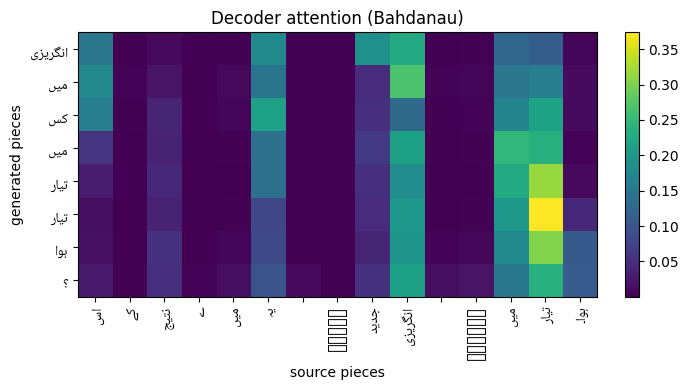

Figure 3 -> results/figures/attention.png
SRC: اس کے نتیجے میں یہ <ans> جدید انگریزی </ans> میں تیار ہوا۔
GEN: انگریزی میں کس میں تیار تیار ہوا؟


In [20]:
# Figure 3 — one attention heat-map (generated pieces x source pieces).
# Matplotlib's default font has no Urdu glyphs; find an Arabic-script font and
# reshape + bidi the labels so they render. Falls back to piece indices.
import glob
import matplotlib.font_manager as fm

URDU_FONT, _reshape = None, (lambda s: s)
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    _reshape = lambda s: get_display(arabic_reshaper.reshape(s))
    # Prefer a proper Naskh/Sans text face; Kufi is decorative and drops glyphs.
    for pat in ["/usr/share/fonts/**/NotoNaskhArabic-Regular.ttf",
                "/usr/share/fonts/**/NotoSansArabic-Regular.ttf",
                "/usr/share/fonts/**/*NotoNaskhArabic*.ttf",
                "/usr/share/fonts/**/*NotoSansArabic*.ttf",
                "/usr/share/fonts/**/*Amiri*.ttf",
                "/usr/share/fonts/**/*[Nn]askh*.ttf",
                "/kaggle/input/**/*rabic*.ttf"]:
        hit = sorted(glob.glob(pat, recursive=True))
        if hit:
            URDU_FONT = fm.FontProperties(fname=hit[0]); break
except Exception:
    pass

def _pick_example():
    """A short source whose greedy question ends in ؟ — makes a readable figure."""
    for s, _ in valid_pairs:
        ids = sp.encode(s, out_type=int)[:MAX_SRC_TOK]
        if not (8 <= len(ids) <= 22):
            continue
        sq, at = greedy_decode(best_model, torch.tensor([ids], device=DEVICE),
                               torch.tensor([len(ids)]), torch.tensor([ids]).eq(PAD).to(DEVICE))
        if 4 <= len(sq[0]) <= 14 and sp.decode(sq[0]).endswith("؟"):
            return s, ids, sq[0], at
    s = valid_pairs[0][0]; ids = sp.encode(s, out_type=int)[:MAX_SRC_TOK]
    sq, at = greedy_decode(best_model, torch.tensor([ids], device=DEVICE),
                           torch.tensor([len(ids)]), torch.tensor([ids]).eq(PAD).to(DEVICE))
    return s, ids, sq[0], at

s_text, ids, gen_ids, attn = _pick_example()
src_pieces = [sp.id_to_piece(i).replace("\u2581", "") or " " for i in ids]
gen_pieces = [sp.id_to_piece(i).replace("\u2581", "") or " " for i in gen_ids]
A = attn[0, : len(gen_pieces), : len(src_pieces)].cpu().numpy()

fig, ax = plt.subplots(figsize=(max(7, len(src_pieces) * 0.45), max(3.5, len(gen_pieces) * 0.5)))
im = ax.imshow(A, aspect="auto", cmap="viridis")
if URDU_FONT is not None:
    ax.set_xticks(range(len(src_pieces)))
    ax.set_xticklabels([_reshape(p) for p in src_pieces], rotation=90, fontsize=9, fontproperties=URDU_FONT)
    ax.set_yticks(range(len(gen_pieces)))
    ax.set_yticklabels([_reshape(p) for p in gen_pieces], fontsize=9, fontproperties=URDU_FONT)
else:  # no Arabic font available — label with indices, print the legend
    ax.set_xticks(range(len(src_pieces))); ax.set_yticks(range(len(gen_pieces)))
    print("source :", " ".join(f"{i}:{p}" for i, p in enumerate(src_pieces)))
    print("generated:", " ".join(f"{i}:{p}" for i, p in enumerate(gen_pieces)))
ax.set_xlabel("source pieces"); ax.set_ylabel("generated pieces")
ax.set_title("Decoder attention (Bahdanau)")
fig.colorbar(im, ax=ax, fraction=0.025)
fig.tight_layout(); fig.savefig(FIG / "attention.png", dpi=140); plt.show()
print("Figure 3 -> results/figures/attention.png")
print("SRC:", s_text)
print("GEN:", sp.decode(gen_ids))

## 9 · Result tables

Tables 1–3 filled from this run; Table 4 is the template the two members complete from
`results/human_eval.csv`.

In [21]:
def T1():
    s = DATA_STATS
    rows = [("Rows in raw dataset", "raw_rows"), ("Answerable rows", "answerable_rows"),
            ("Pairs after length filter", "pairs")]
    out = ["| | Train | Validation | Wiki-UQA |", "|---|---|---|---|"]
    for label, key in rows:
        out.append(f"| {label} | {s['train'][key]} | {s['valid'][key]} | {s['wiki'][key]} |")
    out.append(f"| Mean source / target length | {s['train']['mean_src']} / {s['train']['mean_tgt']} "
               f"| {s['valid']['mean_src']} / {s['valid']['mean_tgt']} "
               f"| {s['wiki']['mean_src']} / {s['wiki']['mean_tgt']} |")
    return "\n".join(out)

def T2():
    m = json.load(open(RES / "train_meta.json"))
    return "\n".join([
        "| Field | Value |", "|---|---|",
        f"| Encoder / decoder | {ENC_LAYERS}-layer BiLSTM / {DEC_LAYERS}-layer LSTM |",
        f"| Layers / embedding / hidden | {ENC_LAYERS} / {EMB_DIM} / {HIDDEN} |",
        "| Attention | Bahdanau (additive) |",
        f"| Vocabulary size | {VOCAB_SIZE} |",
        f"| Trainable parameters | {N_PARAMS:,} |",
        f"| Optimiser / lr / schedule | Adam / {LR} / ReduceLROnPlateau (x{LR_FACTOR}, patience {LR_PATIENCE}) |",
        f"| Batch / epochs / wall-clock / GPU | {m['batch_size']} / {m['epochs']} / "
        f"{m['wall_clock_s']/60:.1f} min / {m['gpu']} |",
    ])

def T3():
    m = outs["UQA valid"]["n_beam"]
    out = ["| Split | Decoding | BLEU-4 | ROUGE-L | PPL | <unk> % |", "|---|---|---|---|---|---|"]
    for split, md_ in METRICS.items():
        for dec, r in md_.items():
            out.append(f"| {split} | {dec} | {r['BLEU-4']} | {r['ROUGE-L']} | {r['PPL']} | {r['unk_%']} |")
    out.append(f"\n_Greedy and beam scored on the same {m} validation examples; "
               f"perplexity on the full split._")
    return "\n".join(out)

T4 = ("| | Fluency | Relevance | Answerability |\n|---|---|---|---|\n"
      "| Member 1 (% yes) | | | |\n| Member 2 (% yes) | | | |\n| Cohen's kappa | | | |")

tables = (f"# Results tables\n\n## Table 1 — Dataset statistics\n\n{T1()}\n\n"
          f"## Table 2 — Model configuration\n\n{T2()}\n\n"
          f"## Table 3 — Automatic metrics\n\n{T3()}\n\n"
          f"## Table 4 — Human evaluation (50 samples)\n\n{T4}\n")
(RES / "tables.md").write_text(tables, encoding="utf-8")
display(Markdown(tables))          # rendered inline; also saved to results/tables.md

# Results tables

## Table 1 — Dataset statistics

| | Train | Validation | Wiki-UQA |
|---|---|---|---|
| Rows in raw dataset | 124745 | 16824 | 210 |
| Answerable rows | 83018 | 11169 | 209 |
| Pairs after length filter | 75236 | 10043 | 177 |
| Mean source / target length | 32.59 / 11.92 | 33.23 / 12.29 | 31.69 / 11.42 |

## Table 2 — Model configuration

| Field | Value |
|---|---|
| Encoder / decoder | 2-layer BiLSTM / 2-layer LSTM |
| Layers / embedding / hidden | 2 / 256 / 512 |
| Attention | Bahdanau (additive) |
| Vocabulary size | 8000 |
| Trainable parameters | 35,505,472 |
| Optimiser / lr / schedule | Adam / 0.001 / ReduceLROnPlateau (x0.5, patience 1) |
| Batch / epochs / wall-clock / GPU | 64 / 15 / 80.6 min / Tesla T4 |

## Table 3 — Automatic metrics

| Split | Decoding | BLEU-4 | ROUGE-L | PPL | <unk> % |
|---|---|---|---|---|---|
| UQA valid | greedy | 5.58 | 0.26 | 34.174 | 0.0 |
| UQA valid | beam(k=5) | 1.02 | 0.1262 | 34.174 | 0.0 |
| Wiki-UQA | greedy | 3.57 | 0.2273 | 50.774 | 0.0 |
| Wiki-UQA | beam(k=5) | 0.32 | 0.0763 | 50.774 | 0.0 |

_Greedy and beam scored on the same 3000 validation examples; perplexity on the full split._

## Table 4 — Human evaluation (50 samples)

| | Fluency | Relevance | Answerability |
|---|---|---|---|
| Member 1 (% yes) | | | |
| Member 2 (% yes) | | | |
| Cohen's kappa | | | |


## 10 · Human evaluation — Cohen's κ helper

Each member fills the `m1_*` / `m2_*` columns of `results/human_eval.csv` with `1` (yes) or
`0` (no), independently. Re-run this cell to get the % yes per criterion and Cohen's κ
between the two raters for Table 4.

In [22]:
def cohen_kappa(a, b):
    a, b = list(a), list(b)
    n = len(a)
    if n == 0:
        return float("nan")
    po = sum(x == y for x, y in zip(a, b)) / n
    pe = sum((a.count(v) / n) * (b.count(v) / n) for v in (0, 1))
    return 1.0 if pe == 1 else (po - pe) / (1 - pe)

def human_eval_report(path=RES / "human_eval.csv"):
    rows = list(csv.DictReader(open(path, encoding="utf-8")))
    filled = [r for r in rows if r["m1_fluency"] != "" and r["m2_fluency"] != ""]
    if not filled:
        print(f"{path}: 0 / {len(rows)} rows rated — fill m1_/m2_ columns with 1/0 first.")
        return
    crit = ["fluency", "relevance", "answerability"]
    print(f"{len(filled)} / {len(rows)} rows rated\n")
    print(f"{'criterion':<15}{'M1 %yes':>9}{'M2 %yes':>9}{'kappa':>9}")
    for c in crit:
        m1 = [int(r[f"m1_{c}"]) for r in filled]
        m2 = [int(r[f"m2_{c}"]) for r in filled]
        print(f"{c:<15}{100*sum(m1)/len(m1):>8.1f}%{100*sum(m2)/len(m2):>8.1f}%{cohen_kappa(m1, m2):>9.3f}")

human_eval_report()

results/human_eval.csv: 0 / 50 rows rated — fill m1_/m2_ columns with 1/0 first.


## 11 · Package outputs

One zip to download and unpack into the local repo, where the front end and the write-ups
use these files.

In [23]:
import shutil
OUT = Path("/kaggle/working/outputs")
for sub in ("artifacts", "results"):
    shutil.copytree(sub, OUT / sub, dirs_exist_ok=True)
for t in ("train.tsv", "valid.tsv", "wiki.tsv"):
    shutil.copy(DATA / t, OUT / t)
shutil.make_archive("/kaggle/working/outputs", "zip", OUT)
print("wrote /kaggle/working/outputs.zip")
!ls -lhR /kaggle/working/outputs

wrote /kaggle/working/outputs.zip
/kaggle/working/outputs:
total 30M
drwxr-xr-x 2 root root 4.0K Sep 10 12:35 artifacts
drwxr-xr-x 3 root root 4.0K Sep 10 13:52 results
-rw-r--r-- 1 root root  27M Sep 10 13:52 train.tsv
-rw-r--r-- 1 root root 3.6M Sep 10 13:52 valid.tsv
-rw-r--r-- 1 root root  65K Sep 10 13:52 wiki.tsv

/kaggle/working/outputs/artifacts:
total 136M
-rw-r--r-- 1 root root 136M Sep 10 13:23 best.pt
-rw-r--r-- 1 root root 381K Sep 10 12:29 ur_sp.model
-rw-r--r-- 1 root root 154K Sep 10 12:29 ur_sp.vocab

/kaggle/working/outputs/results:
total 88K
-rw-r--r-- 1 root root  404 Sep 10 12:29 data_stats.json
drwxr-xr-x 2 root root 4.0K Sep 10 13:52 figures
-rw-r--r-- 1 root root  24K Sep 10 13:52 human_eval.csv
-rw-r--r-- 1 root root  667 Sep 10 13:50 loss_log.csv
-rw-r--r-- 1 root root  581 Sep 10 13:52 metrics.json
-rw-r--r-- 1 root root  29K Sep 10 13:52 samples.tsv
-rw-r--r-- 1 root root 1.4K Sep 10 13:52 tables.md
-rw-r--r-- 1 root root 6.3K Sep 10 12:29 tokenizer_examples